In [1]:
# All imports required for this project
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [2]:
df = pd.read_csv('/Users/evansmith/Desktop/Pineville Porcupine Stats/Pitcher Only Stats Until Jul 4.csv')

In [3]:
df.tail()

,Number,IP,GP,GS,BF,#P,W,L,SV,SVO,...,K/BB,WEAK%,HHB%,GO/AO,HR,LD%,FB%,GB%,BABIP,BA/RISP
18,45,6.0,4,4,39,149,0,1,0,0,...,0.250,86.36,13.64,1.167,1,13.64,31.82,54.55,0.238,0.444
19,47,2.0,1,0,7,32,0,0,0,0,...,4.000,50.00,50.00,0.000,0,50.00,50.00,0.00,0.000,-
20,52,19.2,7,3,100,391,1,1,1,1,...,2.231,64.91,35.09,0.350,1,22.81,42.11,35.09,0.393,0.313
21,53,1.2,1,0,8,25,0,1,0,1,...,0.000,100.0,0.00,1.000,0,0.00,40.00,60.00,0.200,0.500
22,55,6.1,4,1,38,179,0,2,0,1,...,0.455,82.35,17.65,0.200,0,17.65,64.71,17.65,0.294,0.154


In [4]:
df = df.replace("-", 0)
df.drop(columns=["Number"], inplace=True)

In [5]:
df.tail()

,IP,GP,GS,BF,#P,W,L,SV,SVO,BS,...,K/BB,WEAK%,HHB%,GO/AO,HR,LD%,FB%,GB%,BABIP,BA/RISP
18,6.0,4,4,39,149,0,1,0,0,0,...,0.250,86.36,13.64,1.167,1,13.64,31.82,54.55,0.238,0.444
19,2.0,1,0,7,32,0,0,0,0,0,...,4.000,50.00,50.00,0.000,0,50.00,50.00,0.00,0.000,0
20,19.2,7,3,100,391,1,1,1,1,0,...,2.231,64.91,35.09,0.350,1,22.81,42.11,35.09,0.393,0.313
21,1.2,1,0,8,25,0,1,0,1,1,...,0.000,100.0,0.00,1.000,0,0.00,40.00,60.00,0.200,0.500
22,6.1,4,1,38,179,0,2,0,1,1,...,0.455,82.35,17.65,0.200,0,17.65,64.71,17.65,0.294,0.154


In [6]:
df.shape

(23, 58)

# What Correlates to a Successful Outting for a Pitcher (i.e. Win or Loss for a Starter, Save or Blown Save for a RP)

In [7]:
results = []
for col in df.columns:
    if col != 'W' and pd.api.types.is_numeric_dtype(df[col]):
        pair = df[['W', col]].dropna()
        corr, p_value = pearsonr(pair['W'], pair[col])
        results.append((col, corr, p_value))

results.sort(key=lambda x: x[2])

for col, corr, p_value in results:
    print(f'Correlation between Win and {col}: {corr:.4f}, p-value: {p_value:.4g}')

Correlation between Win and 1ST2OUT: 0.6266, p-value: 0.001377
Correlation between Win and SO: 0.5845, p-value: 0.003398
Correlation between Win and K-L: 0.5382, p-value: 0.008068
Correlation between Win and IP: 0.5148, p-value: 0.01195
Correlation between Win and <13: 0.5121, p-value: 0.01248
Correlation between Win and 123INN: 0.5119, p-value: 0.01252
Correlation between Win and LOB: 0.5044, p-value: 0.01412
Correlation between Win and 0BBINN: 0.4995, p-value: 0.01523
Correlation between Win and LOO: 0.4934, p-value: 0.01672
Correlation between Win and BF: 0.4724, p-value: 0.02283
Correlation between Win and GP: 0.4622, p-value: 0.0264
Correlation between Win and #P: 0.4545, p-value: 0.02934
Correlation between Win and BK: 0.4541, p-value: 0.0295
Correlation between Win and PIK: 0.4541, p-value: 0.0295
Correlation between Win and CS: 0.3351, p-value: 0.1181
Correlation between Win and BB: 0.3201, p-value: 0.1365
Correlation between Win and H: 0.3185, p-value: 0.1386
Correlation betwe

In [8]:
results = []
for col in df.columns:
    if col != 'L' and pd.api.types.is_numeric_dtype(df[col]):
        pair = df[['L', col]].dropna()
        corr, p_value = pearsonr(pair['L'], pair[col])
        results.append((col, corr, p_value))

results.sort(key=lambda x: x[2])

for col, corr, p_value in results:
    print(f'Correlation between Loss and {col}: {corr:.4f}, p-value: {p_value:.4g}')

Correlation between Loss and BB: 0.7636, p-value: 2.239e-05
Correlation between Loss and LOBBS: 0.7386, p-value: 5.704e-05
Correlation between Loss and LOBB: 0.7170, p-value: 0.0001182
Correlation between Loss and ER: 0.6739, p-value: 0.0004226
Correlation between Loss and R: 0.6629, p-value: 0.0005668
Correlation between Loss and HBP: 0.6591, p-value: 0.0006246
Correlation between Loss and BBS: 0.6450, p-value: 0.0008907
Correlation between Loss and #P: 0.6066, p-value: 0.00215
Correlation between Loss and BF: 0.5908, p-value: 0.002991
Correlation between Loss and SB: 0.5877, p-value: 0.003186
Correlation between Loss and GP: 0.5601, p-value: 0.00544
Correlation between Loss and LOO: 0.5143, p-value: 0.01204
Correlation between Loss and IP: 0.5127, p-value: 0.01237
Correlation between Loss and LOB: 0.5018, p-value: 0.0147
Correlation between Loss and CS: 0.4850, p-value: 0.01899
Correlation between Loss and BS: 0.4850, p-value: 0.01899
Correlation between Loss and H: 0.4805, p-value: 

In [9]:
results = []
for col in df.columns:
    if col != 'SV' and col != 'SV%' and col != 'SVO' and pd.api.types.is_numeric_dtype(df[col]):
        pair = df[['SV', col]].dropna()
        corr, p_value = pearsonr(pair['SV'], pair[col])
        results.append((col, corr, p_value))

results.sort(key=lambda x: x[2])

for col, corr, p_value in results:
    print(f'Correlation between Save and {col}: {corr:.4f}, p-value: {p_value:.4g}')

Correlation between Save and 1ST2OUT: 0.5572, p-value: 0.005745
Correlation between Save and 0BBINN: 0.5381, p-value: 0.008082
Correlation between Save and 123INN: 0.5164, p-value: 0.01164
Correlation between Save and <13: 0.4344, p-value: 0.03834
Correlation between Save and FPS%: 0.4245, p-value: 0.0435
Correlation between Save and LOO: 0.4218, p-value: 0.04497
Correlation between Save and H: 0.4184, p-value: 0.04694
Correlation between Save and BK: 0.4045, p-value: 0.05555
Correlation between Save and PIK: 0.4045, p-value: 0.05555
Correlation between Save and <3%: 0.4023, p-value: 0.05702
Correlation between Save and SO: 0.4009, p-value: 0.05796
Correlation between Save and IP: 0.3928, p-value: 0.06375
Correlation between Save and GP: 0.3804, p-value: 0.07334
Correlation between Save and LOB: 0.3762, p-value: 0.07683
Correlation between Save and BB/INN: -0.3677, p-value: 0.0843
Correlation between Save and FIP: -0.3587, p-value: 0.09276
Correlation between Save and S%: 0.3517, p-val

In [10]:
results = []
for col in df.columns:
    if col != 'BS' and col != 'L' and col != 'SV' and col != 'SV%' and col != 'SVO' and pd.api.types.is_numeric_dtype(df[col]):
        pair = df[['BS', col]].dropna()
        corr, p_value = pearsonr(pair['BS'], pair[col])
        results.append((col, corr, p_value))

results.sort(key=lambda x: x[2])

for col, corr, p_value in results:
    print(f'Correlation between Blown Saves and {col}: {corr:.4f}, p-value: {p_value:.4g}')

Correlation between Blown Saves and LOBBS: 0.4496, p-value: 0.03136
Correlation between Blown Saves and FPSW%: 0.4350, p-value: 0.03806
Correlation between Blown Saves and FIP: 0.3187, p-value: 0.1383
Correlation between Blown Saves and S%: -0.2798, p-value: 0.196
Correlation between Blown Saves and BB/INN: 0.2698, p-value: 0.2132
Correlation between Blown Saves and HBP: 0.2628, p-value: 0.2257
Correlation between Blown Saves and GS: -0.2547, p-value: 0.2409
Correlation between Blown Saves and HR: 0.2434, p-value: 0.263
Correlation between Blown Saves and FPSO%: -0.2268, p-value: 0.2979
Correlation between Blown Saves and K/BF: -0.2215, p-value: 0.3098
Correlation between Blown Saves and FPS%: -0.2185, p-value: 0.3165
Correlation between Blown Saves and BBS: 0.2076, p-value: 0.342
Correlation between Blown Saves and P/BF: -0.1955, p-value: 0.3713
Correlation between Blown Saves and W: 0.1745, p-value: 0.4258
Correlation between Blown Saves and LOBB: 0.1244, p-value: 0.5718
Correlation 

# Graphs for pitchers

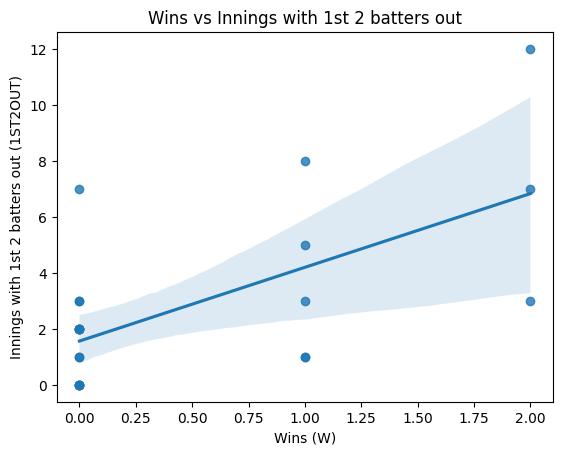

In [11]:
# Plots the calculated correlation and shows the line of best fit
sns.regplot(data=df, x="W", y="1ST2OUT")

plt.title("Wins vs Innings with 1st 2 batters out")
plt.xlabel("Wins (W)")
plt.ylabel("Innings with 1st 2 batters out (1ST2OUT)")

plt.show()

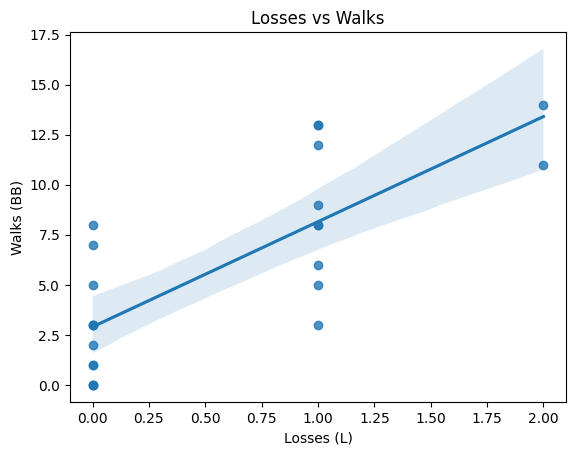

In [12]:
# Plots the calculated correlation and shows the line of best fit
sns.regplot(data=df, x="L", y="BB")

plt.title("Losses vs Walks")
plt.xlabel("Losses (L)")
plt.ylabel("Walks (BB)")

plt.show()

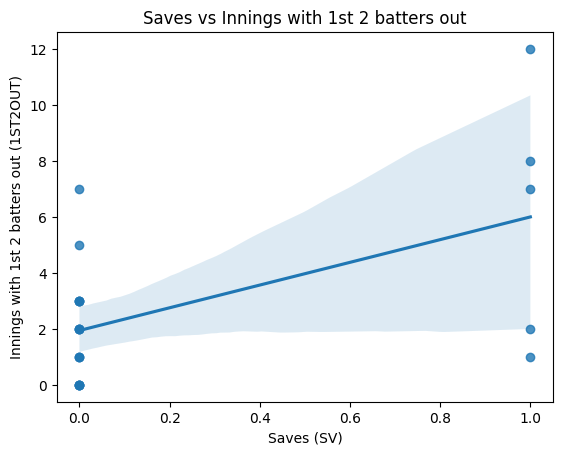

In [13]:
# Plots the calculated correlation and shows the line of best fit
sns.regplot(data=df, x="SV", y="1ST2OUT")

plt.title("Saves vs Innings with 1st 2 batters out")
plt.xlabel("Saves (SV)")
plt.ylabel("Innings with 1st 2 batters out (1ST2OUT)")

plt.show()

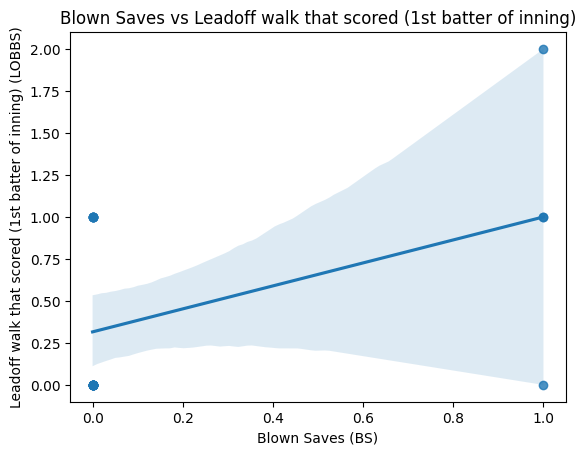

In [14]:
# Plots the calculated correlation and shows the line of best fit
sns.regplot(data=df, x="BS", y="LOBBS")

plt.title("Blown Saves vs Leadoff walk that scored (1st batter of inning)")
plt.xlabel("Blown Saves (BS)")
plt.ylabel("Leadoff walk that scored (1st batter of inning) (LOBBS)")

plt.show()

# Hitting Correlations

In [15]:
df1 = pd.read_csv('/Users/evansmith/Desktop/Pineville Porcupine Stats/Hitter Only Stats Until Jul 4.csv')

In [16]:
df1.tail()

,Number,Last,First,GP,PA,AB,AVG,OBP,OPS,SLG,...,XBH,TB,PS,PS/PA,2S+3,2S+3%,6,6%,AB/HR,GIDP
21,35,Sanders,Brody,15,47,35,0.343,0.447,0.847,0.400,...,2,14,176,3.745,3,6.38,8,17.02,-,0
22,38,Crayton,Michael,3,1,1,0.000,0.000,0.000,0.000,...,0,0,17,17.00,1,100.0,1,100.0,-,1
23,44,Rogers,Michael,23,91,80,0.338,0.407,0.832,0.425,...,6,34,330,3.626,12,13.19,14,15.38,-,3
24,45,Douglas,Jacob,1,0,0,-,-,0.000,-,...,0,0,0,-,0,-,0,-,-,0
25,53,Schwamb,Samuel,12,37,35,0.314,0.351,0.808,0.457,...,3,16,126,3.405,6,16.22,5,13.51,35.0,0


In [17]:
df1 = df1.replace("-", 0)
df1.drop(columns=["Number"], inplace=True)
df1.drop(columns=["Last"], inplace=True)
df1.drop(columns=["First"], inplace=True)

In [18]:
df1.tail()

,GP,PA,AB,AVG,OBP,OPS,SLG,H,1B,2B,...,XBH,TB,PS,PS/PA,2S+3,2S+3%,6,6%,AB/HR,GIDP
21,15,47,35,0.343,0.447,0.847,0.400,12,10,2,...,2,14,176,3.745,3,6.38,8,17.02,0,0
22,3,1,1,0.000,0.000,0.000,0.000,0,0,0,...,0,0,17,17.00,1,100.0,1,100.0,0,1
23,23,91,80,0.338,0.407,0.832,0.425,27,21,5,...,6,34,330,3.626,12,13.19,14,15.38,0,3
24,1,0,0,0,0,0.000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
25,12,37,35,0.314,0.351,0.808,0.457,11,8,2,...,3,16,126,3.405,6,16.22,5,13.51,35.0,0


In [19]:
cols_to_clean = ['AVG', 'OBP', 'SLG', 'SB%', 'QAB%', 'PA/BB', 'C%', 'LD%', 'FB%',
                  'GB%', 'BABIP', 'BA/RISP', 'PS/PA', '2S+3%', '6%', 'AB/HR']

for col in cols_to_clean:
    df1[col] = pd.to_numeric(df1[col].replace('-', pd.NA), errors='coerce')

In [20]:
results = []
for col in df1.columns:
    if col != 'OBP' and pd.api.types.is_numeric_dtype(df1[col]):
        pair = df1[['OBP', col]].dropna()
        corr, p_value = pearsonr(pair['OBP'], pair[col])
        results.append((col, corr, p_value))

results.sort(key=lambda x: x[2])

for col, corr, p_value in results:
    print(f'Correlation between On Base Percentage and {col}: {corr:.4f}, p-value: {p_value:.4g}')

Correlation between On Base Percentage and OPS: 0.9605, p-value: 7.811e-15
Correlation between On Base Percentage and AVG: 0.9024, p-value: 2.965e-10
Correlation between On Base Percentage and SLG: 0.8657, p-value: 1.13e-08
Correlation between On Base Percentage and BABIP: 0.8633, p-value: 1.37e-08
Correlation between On Base Percentage and BA/RISP: 0.8088, p-value: 5.71e-07
Correlation between On Base Percentage and BB/K: 0.6367, p-value: 0.0004697
Correlation between On Base Percentage and SB%: 0.6233, p-value: 0.0006694
Correlation between On Base Percentage and LD%: 0.6128, p-value: 0.0008736
Correlation between On Base Percentage and QAB: 0.5921, p-value: 0.001439
Correlation between On Base Percentage and GP: 0.5906, p-value: 0.001491
Correlation between On Base Percentage and PA: 0.5881, p-value: 0.001578
Correlation between On Base Percentage and PS: 0.5783, p-value: 0.00197
Correlation between On Base Percentage and H: 0.5713, p-value: 0.002302
Correlation between On Base Perc

In [21]:
results = []
for col in df1.columns:
    if col != 'R' and pd.api.types.is_numeric_dtype(df1[col]):
        pair = df1[['R', col]].dropna()
        corr, p_value = pearsonr(pair['R'], pair[col])
        results.append((col, corr, p_value))

results.sort(key=lambda x: x[2])

for col, corr, p_value in results:
    print(f'Correlation between Runs Scored and {col}: {corr:.4f}, p-value: {p_value:.4g}')

Correlation between Runs Scored and PA: 0.9322, p-value: 4.391e-12
Correlation between Runs Scored and QAB: 0.9282, p-value: 8.616e-12
Correlation between Runs Scored and H: 0.9240, p-value: 1.652e-11
Correlation between Runs Scored and PS: 0.9179, p-value: 4.042e-11
Correlation between Runs Scored and TB: 0.9178, p-value: 4.087e-11
Correlation between Runs Scored and RBI: 0.9147, p-value: 6.297e-11
Correlation between Runs Scored and AB: 0.9147, p-value: 6.301e-11
Correlation between Runs Scored and HHB: 0.8986, p-value: 4.615e-10
Correlation between Runs Scored and 1B: 0.8837, p-value: 2.204e-09
Correlation between Runs Scored and GP: 0.8801, p-value: 3.115e-09
Correlation between Runs Scored and SB: 0.8704, p-value: 7.55e-09
Correlation between Runs Scored and 2OUTRBI: 0.8579, p-value: 2.13e-08
Correlation between Runs Scored and XBH: 0.8489, p-value: 4.229e-08
Correlation between Runs Scored and BB: 0.8442, p-value: 5.955e-08
Correlation between Runs Scored and 2B: 0.8432, p-value:

# Graphs For Hitters

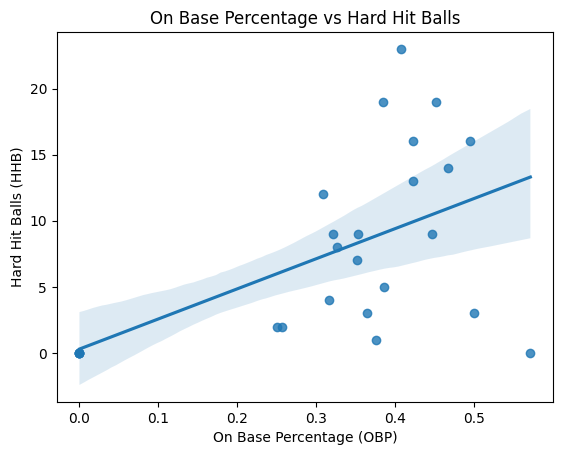

In [22]:
# Plots the calculated correlation and shows the line of best fit
sns.regplot(data=df1, x="OBP", y="HHB")

plt.title("On Base Percentage vs Hard Hit Balls")
plt.xlabel("On Base Percentage (OBP)")
plt.ylabel("Hard Hit Balls (HHB)")

plt.show()

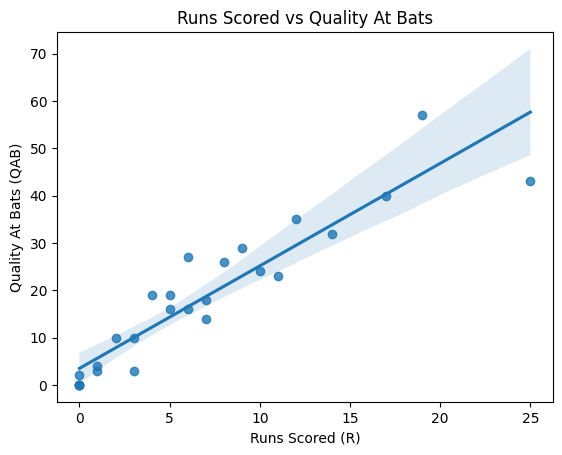

In [23]:
# Plots the calculated correlation and shows the line of best fit
sns.regplot(data=df1, x="R", y="QAB")

plt.title("Runs Scored vs Quality At Bats")
plt.xlabel("Runs Scored (R)")
plt.ylabel("Quality At Bats (QAB)")

plt.show()

### A Quality AB is any one of 3 pitches after 2 strikes, 6+ pitch ABs, XBH, HHB, BB, SAC Bunt, SAC Fly

# Other Interesting Finds

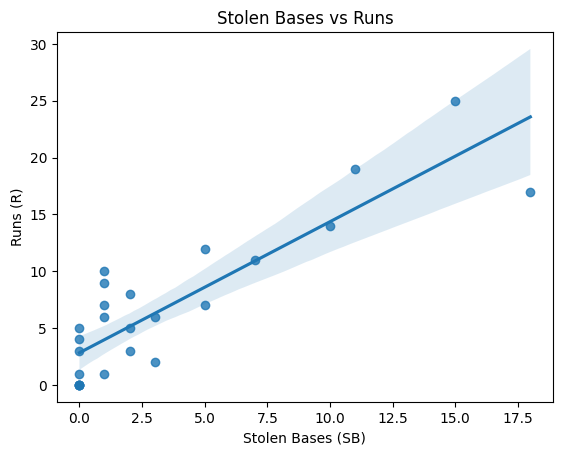

In [24]:
# Plots the calculated correlation and shows the line of best fit
sns.regplot(data=df1, x="SB", y="R")

plt.title("Stolen Bases vs Runs")
plt.xlabel("Stolen Bases (SB)")
plt.ylabel("Runs (R)")

plt.show()

### Stolen Bases leads to runs scored

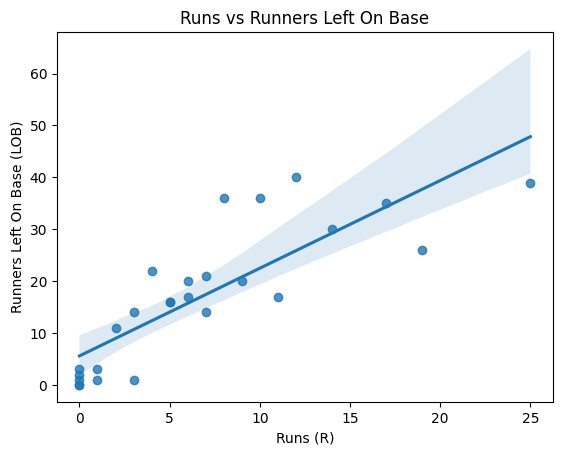

In [25]:
# Plots the calculated correlation and shows the line of best fit
sns.regplot(data=df1, x="R", y="LOB")

plt.title("Runs vs Runners Left On Base")
plt.xlabel("Runs (R)")
plt.ylabel("Runners Left On Base (LOB)")

plt.show()

### Leaving runners on base leads to runs?

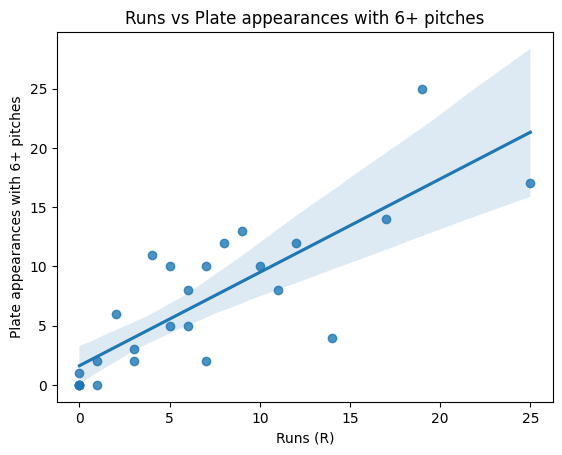

In [26]:
# Plots the calculated correlation and shows the line of best fit
sns.regplot(data=df1, x="R", y="6")

plt.title("Runs vs Plate appearances with 6+ pitches")
plt.xlabel("Runs (R)")
plt.ylabel("Plate appearances with 6+ pitches")

plt.show()

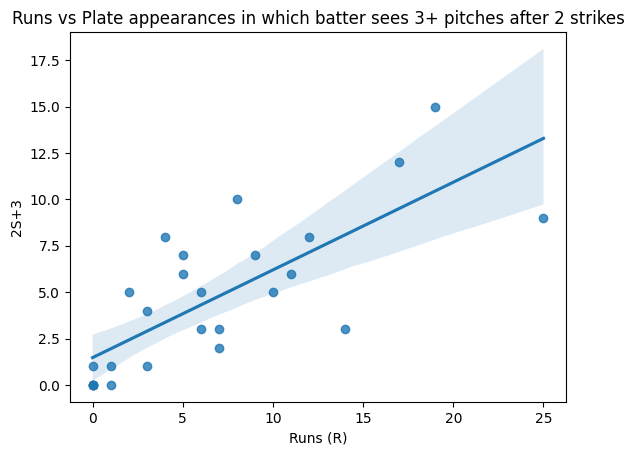

In [27]:
# Plots the calculated correlation and shows the line of best fit
sns.regplot(data=df1, x="R", y="2S+3")

plt.title("Runs vs Plate appearances in which batter sees 3+ pitches after 2 strikes")
plt.xlabel("Runs (R)")
plt.ylabel("2S+3")

plt.show()

### Long ABs lead to runs scored

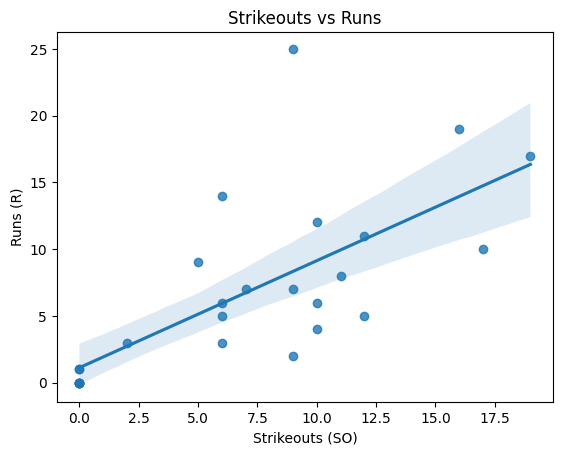

In [28]:
# Plots the calculated correlation and shows the line of best fit
sns.regplot(data=df1, x="SO", y="R")

plt.title("Strikeouts vs Runs")
plt.xlabel("Strikeouts (SO)")
plt.ylabel("Runs (R)")

plt.show()

### Strikeouts leads to runs?